In [184]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib as plt

In [185]:
DB = r"C:\Users\Phongsathorn\Documents\Portfolio\01. Project\P03 E-commerce\to git hub\notebook\dataset\olist.sqlite"
conn = sqlite3.Connection(DB)

In [186]:
output_pict = r"output"

In [187]:
def query(sql,connect = conn):
    df = pd.read_sql(sql,connect)
    return df

In [188]:
q = """
select * from sqlite_master
"""

df = query(q)
df

,type,name,tbl_name,rootpage,sql
0,table,product_category_name_translation,product_category_name_translation,2,"CREATE TABLE ""product_category_name_translatio..."
1,table,sellers,sellers,3,"CREATE TABLE ""sellers"" (\n""seller_id"" TEXT,\n ..."
2,table,customers,customers,48,"CREATE TABLE ""customers"" (\n""customer_id"" TEXT..."
3,table,geolocation,geolocation,2282,"CREATE TABLE ""geolocation"" (\n""geolocation_zip..."
4,table,order_items,order_items,12881,"CREATE TABLE ""order_items"" (\n""order_id"" TEXT,..."
5,table,order_payments,order_payments,16916,"CREATE TABLE ""order_payments"" (\n""order_id"" TE..."
6,table,order_reviews,order_reviews,18508,"CREATE TABLE ""order_reviews"" (\n""review_id"" TE..."
7,table,orders,orders,22174,"CREATE TABLE ""orders"" (\n""order_id"" TEXT,\n ""..."
8,table,products,products,26706,"CREATE TABLE ""products"" (\n""product_id"" TEXT,\..."
9,table,leads_qualified,leads_qualified,27283,"CREATE TABLE ""leads_qualified"" (\n""mql_id"" TEX..."


In [189]:
translation  = query("select * from product_category_name_translation")
seller      = query("select * from sellers")
customer    = query("select * from customers")
item  = query("select * from order_items")
payment     = query("select * from order_payments")
review = query("select * from order_reviews")
order = query("select * from orders")
product = query("select * from products")
leads_closed = query("select * from leads_closed")
leads_qualified = query("select * from leads_qualified")

In [190]:
# ตรวจสอบขนาดแต่ละ table
for name, df in {
    "orders"      : order,
    "order_items" : item,
    "customers"   : customer,
    "products"    : product,
    "sellers"     : seller,
    "payments"    : payment,
    "reviews"     : review,
    "translation" : translation,
}.items():
    print(f"{name:<15} {df.shape}")

orders          (99441, 8)
order_items     (112650, 7)
customers       (99441, 5)
products        (32951, 9)
sellers         (3095, 4)
payments        (103886, 5)
reviews         (99224, 7)
translation     (71, 2)


In [192]:
# ── 1. แปลง datetime columns ──────────────────────────
datetime_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in datetime_cols:
    order[col] = pd.to_datetime(order[col])

review['review_creation_date']    = pd.to_datetime(review['review_creation_date'],yearfirst=True,errors="coerce")
review['review_answer_timestamp'] = pd.to_datetime(review['review_answer_timestamp'],yearfirst=True,errors="coerce")

# ── 2. Missing Values ทุก table ───────────────────────
def missing_summary(df, name):
    m = df.isnull().sum()
    m = m[m > 0]
    if len(m) == 0:
        print(f"{name:<15} No missing values")
    else:
        pct = (m / len(df) * 100).round(2)
        result = pd.DataFrame({'missing': m, 'pct(%)': pct})
        print(f"\n{name}")
        print(result)

for df, name in [
    (order,      'orders'),
    (item, 'order_items'),
    (customer,   'customers'),
    (product,    'products'),
    (review,     'reviews'),
    (payment,    'payments'),
]:
    missing_summary(df, name)


orders
                               missing  pct(%)
order_approved_at                  160    0.16
order_delivered_carrier_date      1783    1.79
order_delivered_customer_date     2965    2.98
order_items     No missing values
customers       No missing values

products
                            missing  pct(%)
product_category_name           610    1.85
product_name_lenght             610    1.85
product_description_lenght      610    1.85
product_photos_qty              610    1.85
product_weight_g                  2    0.01
product_length_cm                 2    0.01
product_height_cm                 2    0.01
product_width_cm                  2    0.01

reviews
                        missing  pct(%)
review_comment_title      87656   88.34
review_comment_message    58247   58.70
payments        No missing values


In [167]:
# ── 1. orders — missing datetime ─────────────────────
# strategy: เก็บไว้ก่อน กรองตอนใช้งานด้วย order_status แทน
# เพราะ delivered = มีวันครบ, cancelled = ไม่มีวันจัดส่ง เป็นเรื่องปกติ

print("=== orders: missing by status ===")
print(
    order.groupby('order_status')
    ['order_delivered_customer_date']
    .apply(lambda x: x.isnull().sum())
    .reset_index(name='missing_delivered_date')
)


=== orders: missing by status ===
  order_status  missing_delivered_date
0     approved                       2
1     canceled                     619
2      created                       5
3    delivered                       8
4     invoiced                     314
5   processing                     301
6      shipped                    1107
7  unavailable                     609


In [168]:

# ── 2. products — missing category ───────────────────
# strategy: เติม 'unknown' ไว้ก่อน เพื่อไม่ให้หายออกจาก analysis
print("\n=== products: missing category ===")
print(f"Before: {product['product_category_name'].isnull().sum()} missing")

product['product_category_name'] = (
    product['product_category_name'].fillna('unknown')
)
print(f"After : {product['product_category_name'].isnull().sum()} missing")



=== products: missing category ===
Before: 610 missing
After : 0 missing


In [169]:

# ── 3. reviews — missing comment ─────────────────────
# strategy: ไม่ต้องแก้ เพราะใช้แค่ review_score เป็นหลัก
print("\n=== reviews: missing summary ===")
print(review.isnull().sum()[review.isnull().sum() > 0])
print("\nreview_score missing:",
      review['review_score'].isnull().sum())


=== reviews: missing summary ===
review_comment_title      87656
review_comment_message    58247
dtype: int64

review_score missing: 0


## Create Master Table

In [170]:
order["day_prep_item"] = (order["order_delivered_carrier_date"].dt.normalize() - order["order_purchase_timestamp"].dt.normalize()).dt.days
order["day_delivery"] = (order["order_delivered_customer_date"].dt.normalize() - order["order_delivered_carrier_date"].dt.normalize()).dt.days
order["actual_delivery_days"] = (order["order_delivered_customer_date"].dt.normalize() - order["order_purchase_timestamp"].dt.normalize()).dt.days
order["estimated_delivery_days"] = (order["order_estimated_delivery_date"].dt.normalize() - order["order_purchase_timestamp"].dt.normalize()).dt.days
order["is_late"] = np.where(order["order_estimated_delivery_date"].dt.normalize().lt(order["order_delivered_customer_date"]),1,0)
order[["day_prep_item","day_delivery"]] = order[["day_prep_item","day_delivery"]].fillna(0)
order

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,day_prep_item,day_delivery,actual_delivery_days,estimated_delivery_days,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2.0,6.0,8.0,16,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2.0,12.0,14.0,20,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,0.0,9.0,9.0,27,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,4.0,10.0,14.0,27,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1.0,2.0,3.0,13,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,1.0,7.0,8.0,19,0
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,1.0,21.0,22.0,24,0
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,1.0,24.0,25.0,31,0
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,4.0,13.0,17.0,38,0


In [171]:
agg_item = item.groupby(["order_id","product_id","seller_id"]).agg(
    count_items = ("order_item_id","max")
    ,total_price = ("price","sum")
    ,total_freight = ("freight_value","sum")
).reset_index().copy()

agg_item

,order_id,product_id,seller_id,count_items,total_price,total_freight
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,1,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,1,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,1,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,1,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,1,199.90,18.14
...,...,...,...,...,...,...
102420,fffc94f6ce00a00581880bf54a75a037,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,1,299.99,43.41
102421,fffcd46ef2263f404302a634eb57f7eb,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,1,350.00,36.53
102422,fffce4705a9662cd70adb13d4a31832d,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,1,99.90,16.95
102423,fffe18544ffabc95dfada21779c9644f,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,1,55.99,8.72


In [172]:
agg_payment = payment.groupby(["order_id","payment_type"]).agg(max_installments = ("payment_installments","max")
                                                 ,total_value = ("payment_value","sum")).reset_index().copy()

agg_payment

,order_id,payment_type,max_installments,total_value
0,00010242fe8c5a6d1ba2dd792cb16214,credit_card,2,72.19
1,00018f77f2f0320c557190d7a144bdd3,credit_card,3,259.83
2,000229ec398224ef6ca0657da4fc703e,credit_card,5,216.87
3,00024acbcdf0a6daa1e931b038114c75,credit_card,2,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,credit_card,3,218.04
...,...,...,...,...
101681,fffc94f6ce00a00581880bf54a75a037,boleto,1,343.40
101682,fffcd46ef2263f404302a634eb57f7eb,boleto,1,386.53
101683,fffce4705a9662cd70adb13d4a31832d,credit_card,3,116.85
101684,fffe18544ffabc95dfada21779c9644f,credit_card,3,64.71


In [173]:
review["day_comment"] = (review["review_answer_timestamp"].dt.normalize() - review["review_creation_date"]).dt.days

agg_review = review.groupby("order_id").agg(review_score = ("review_score","mean")
                               ,day_comment = ("day_comment","sum")).reset_index()

agg_review

,order_id,review_score,day_comment
0,00010242fe8c5a6d1ba2dd792cb16214,5.0,1
1,00018f77f2f0320c557190d7a144bdd3,4.0,2
2,000229ec398224ef6ca0657da4fc703e,5.0,0
3,00024acbcdf0a6daa1e931b038114c75,4.0,0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0,1
...,...,...,...
98668,fffc94f6ce00a00581880bf54a75a037,5.0,3
98669,fffcd46ef2263f404302a634eb57f7eb,5.0,1
98670,fffce4705a9662cd70adb13d4a31832d,5.0,0
98671,fffe18544ffabc95dfada21779c9644f,5.0,1


In [174]:
prod_trans = product.merge(translation,"outer","product_category_name")[["product_id","product_category_name_english"]]
prod_trans

,product_id,product_category_name_english
0,07f01b6fcacc1b187a71e5074199db2d,agro_industry_and_commerce
1,613d093272cb8f74f25a01e430155a6a,agro_industry_and_commerce
2,980ecbcc15fe174ec1e5757c4d75b1bf,agro_industry_and_commerce
3,ba1d7e7ee1f055d252a2faa8ea3cea9b,agro_industry_and_commerce
4,137ace556a03792cdc43f91ec621426d,agro_industry_and_commerce
...,...,...
32946,5f24a2c5fe04fac8072d899fffa77540,housewares
32947,70bf4f61950297cf24e18a9b84c3208a,housewares
32948,44493ebe02de3fd58d529f40fd2944d1,housewares
32949,29c5f56bdaf7929e981f654f1a2f79ec,housewares


In [175]:
df2 = (
    order.loc[order["order_status"].eq("delivered")]
    .merge(customer,how="left",on="customer_id")
    .merge(agg_item,how="left",on="order_id")
    .merge(agg_payment,how="left",on="order_id")
    .merge(agg_review,how="left",on="order_id")
    .merge(prod_trans,how="left",on="product_id")
)

df2["freight_ratio"] = df2["total_freight"]/df2["total_price"]
df2.info()
df2

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102472 entries, 0 to 102471
Data columns (total 29 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       102472 non-null  object        
 1   customer_id                    102472 non-null  object        
 2   order_status                   102472 non-null  object        
 3   order_purchase_timestamp       102472 non-null  datetime64[ns]
 4   order_approved_at              102458 non-null  datetime64[ns]
 5   order_delivered_carrier_date   102470 non-null  datetime64[ns]
 6   order_delivered_customer_date  102464 non-null  datetime64[ns]
 7   order_estimated_delivery_date  102472 non-null  datetime64[ns]
 8   day_prep_item                  102472 non-null  float64       
 9   day_delivery                   102472 non-null  float64       
 10  actual_delivery_days           102464 non-null  float64       
 11  

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,day_prep_item,day_delivery,...,count_items,total_price,total_freight,payment_type,max_installments,total_value,review_score,day_comment,product_category_name_english,freight_ratio
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2.0,6.0,...,1,29.99,8.72,credit_card,1.0,18.12,4.0,1.0,housewares,0.290764
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2.0,6.0,...,1,29.99,8.72,voucher,1.0,20.59,4.0,1.0,housewares,0.290764
2,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2.0,12.0,...,1,118.70,22.76,boleto,1.0,141.46,4.0,0.0,perfumery,0.191744
3,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,0.0,9.0,...,1,159.90,19.22,credit_card,3.0,179.12,5.0,4.0,auto,0.120200
4,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,4.0,10.0,...,1,45.00,27.20,credit_card,1.0,72.20,5.0,2.0,pet_shop,0.604444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102467,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,1.0,7.0,...,1,72.00,13.08,credit_card,3.0,85.08,5.0,1.0,health_beauty,0.181667
102468,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,1.0,21.0,...,1,174.90,20.10,credit_card,3.0,195.00,4.0,1.0,baby,0.114923
102469,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,1.0,24.0,...,1,205.99,65.02,credit_card,5.0,271.01,5.0,0.0,home_appliances_2,0.315646
102470,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,4.0,13.0,...,2,359.98,81.18,credit_card,4.0,441.16,2.0,1.0,computers_accessories,0.225513


In [176]:
df2["month_purchase"] = np.where(df2["order_purchase_timestamp"].dt.month.lt(10),"0"+df2["order_purchase_timestamp"].dt.month.astype(str),df2["order_purchase_timestamp"].dt.month.astype(str))
df2["year_purchase"] = df2["order_purchase_timestamp"].dt.year.astype(str)
df2["d_cal"] = df2["year_purchase"] + "_" + df2["month_purchase"]
df2

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,day_prep_item,day_delivery,...,payment_type,max_installments,total_value,review_score,day_comment,product_category_name_english,freight_ratio,month_purchase,year_purchase,d_cal
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2.0,6.0,...,credit_card,1.0,18.12,4.0,1.0,housewares,0.290764,10,2017,2017_10
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2.0,6.0,...,voucher,1.0,20.59,4.0,1.0,housewares,0.290764,10,2017,2017_10
2,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2.0,12.0,...,boleto,1.0,141.46,4.0,0.0,perfumery,0.191744,07,2018,2018_07
3,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,0.0,9.0,...,credit_card,3.0,179.12,5.0,4.0,auto,0.120200,08,2018,2018_08
4,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,4.0,10.0,...,credit_card,1.0,72.20,5.0,2.0,pet_shop,0.604444,11,2017,2017_11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102467,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,1.0,7.0,...,credit_card,3.0,85.08,5.0,1.0,health_beauty,0.181667,03,2017,2017_03
102468,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,1.0,21.0,...,credit_card,3.0,195.00,4.0,1.0,baby,0.114923,02,2018,2018_02
102469,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,1.0,24.0,...,credit_card,5.0,271.01,5.0,0.0,home_appliances_2,0.315646,08,2017,2017_08
102470,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,4.0,13.0,...,credit_card,4.0,441.16,2.0,1.0,computers_accessories,0.225513,01,2018,2018_01


In [177]:
import matplotlib.pyplot as plt
import seaborn as sns

# ตรวจสอบว่า import ถูกต้อง
print(plt.__version__ if hasattr(plt, '__version__') else "plt imported OK")
print("sns version:", sns.__version__)

plt imported OK
sns version: 0.13.2


<>:34: SyntaxWarning: invalid escape sequence '\B'
<>:34: SyntaxWarning: invalid escape sequence '\B'
C:\Users\Phongsathorn\AppData\Local\Temp\ipykernel_31616\820803952.py:34: SyntaxWarning: invalid escape sequence '\B'
  plt.savefig(output_pict + "\BQ1_monthly_revenue.png", dpi=150)


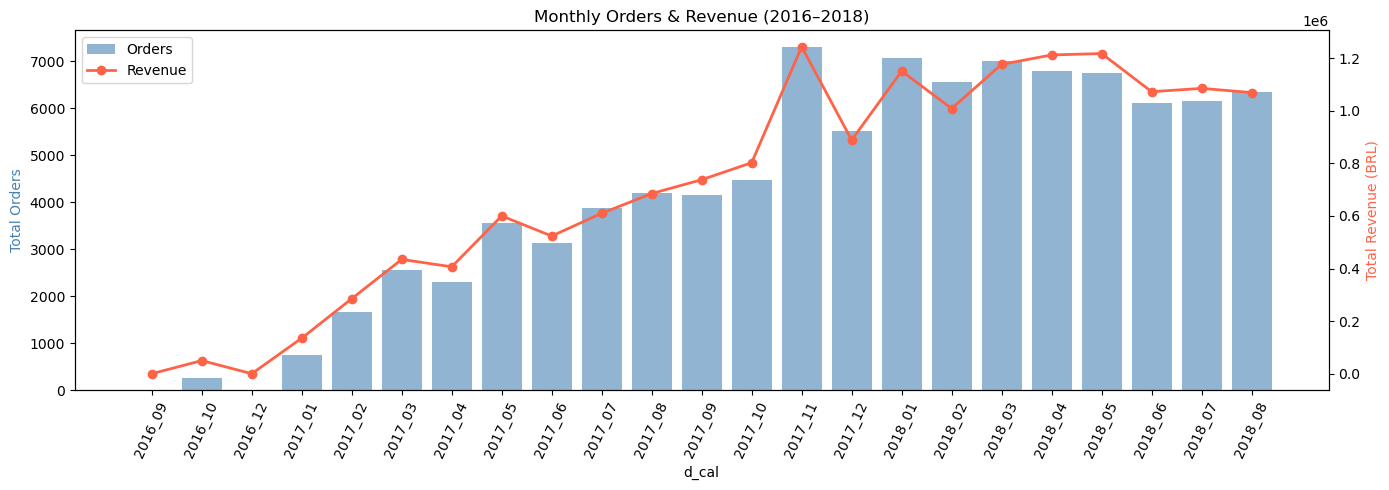

Peak month   : 2017_11
Peak revenue : 1,244,124 BRL
Peak orders  : 7,289


In [178]:
# ── BQ1.2 Monthly Revenue & Orders ──────────────────────
monthly = (
    df2.groupby('d_cal')
    .agg(
        total_orders  = ('order_id',    'nunique'),
        total_revenue = ('total_value', 'sum')
    )
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

# Bar: Orders
ax1.bar(monthly['d_cal'], monthly['total_orders'],
        color='steelblue', alpha=0.6, label='Orders')

# Line: Revenue
ax2.plot(monthly['d_cal'], monthly['total_revenue'],
         color='tomato', marker='o', linewidth=2, label='Revenue')

ax1.set_xlabel('d_cal')
ax1.set_ylabel('Total Orders', color='steelblue')
ax2.set_ylabel('Total Revenue (BRL)', color='tomato')
ax1.tick_params(axis='x', rotation=65)
plt.title('Monthly Orders & Revenue (2016–2018)')

# Legend รวม 2 axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig(output_pict + "\BQ1_monthly_revenue.png", dpi=150)
plt.show()

# ── Insight ──────────────────────────────────────────────
peak = monthly.loc[monthly['total_revenue'].idxmax()]
print(f"Peak month   : {peak['d_cal']}")
print(f"Peak revenue : {peak['total_revenue']:,.0f} BRL")
print(f"Peak orders  : {peak['total_orders']:,}")

<>:46: SyntaxWarning: invalid escape sequence '\B'
<>:46: SyntaxWarning: invalid escape sequence '\B'
C:\Users\Phongsathorn\AppData\Local\Temp\ipykernel_31616\3732061872.py:46: SyntaxWarning: invalid escape sequence '\B'
  plt.savefig(output_pict + "\BQ2_customer.png", dpi=150)


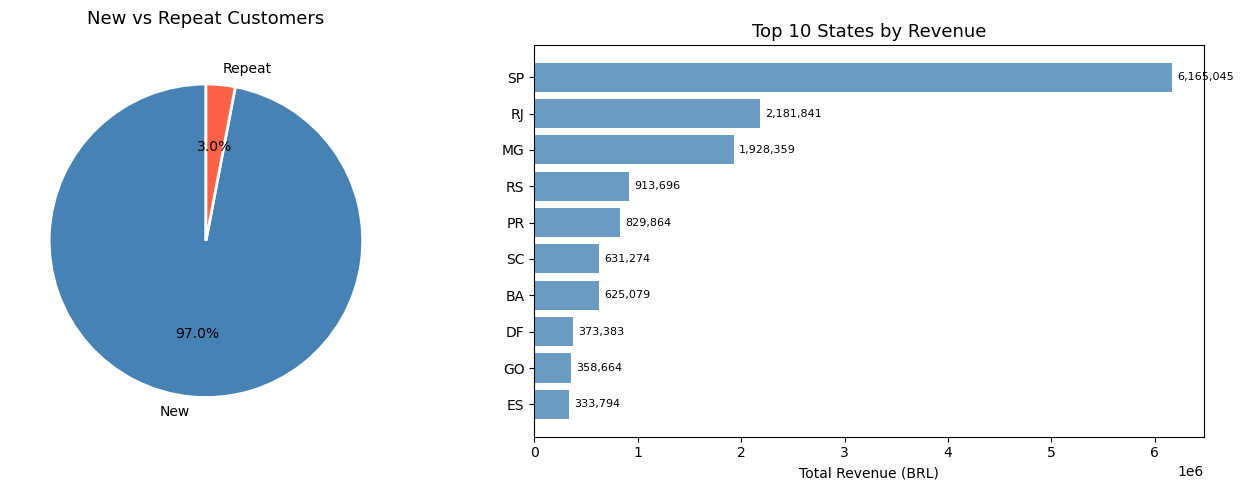

Repeat customer rate : 3.00%
Top state by revenue : SP


In [179]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── BQ2.1 New vs Repeat ──────────────────────────────────
repeat = (
    df2.groupby('customer_unique_id')['order_id']
    .nunique()
    .reset_index(name='order_count')
)
repeat['type'] = repeat['order_count'].apply(
    lambda x: 'Repeat' if x > 1 else 'New'
)
ctype = repeat['type'].value_counts()

axes[0].pie(
    ctype,
    labels   = ctype.index,
    autopct  = '%1.1f%%',
    colors   = ['steelblue', 'tomato'],
    startangle = 90,
    wedgeprops = {'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('New vs Repeat Customers', fontsize=13, pad=15)

# ── BQ2.2 Top 10 States by Revenue ───────────────────────
state_rev = (
    df2.groupby('customer_state')['total_value']
    .sum()
    .nlargest(10)
    .reset_index()
    .sort_values('total_value')
)

axes[1].barh(
    state_rev['customer_state'],
    state_rev['total_value'],
    color='steelblue', alpha=0.8
)
axes[1].set_title('Top 10 States by Revenue', fontsize=13)
axes[1].set_xlabel('Total Revenue (BRL)')

# ใส่ตัวเลขบน bar
for i, v in enumerate(state_rev['total_value']):
    axes[1].text(v + 50000, i, f'{v:,.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(output_pict + "\BQ2_customer.png", dpi=150)
plt.show()

# ── Insight ──────────────────────────────────────────────
repeat_rate = (repeat['type'] == 'Repeat').mean() * 100
print(f"Repeat customer rate : {repeat_rate:.2f}%")
print(f"Top state by revenue : {state_rev.iloc[-1]['customer_state']}")

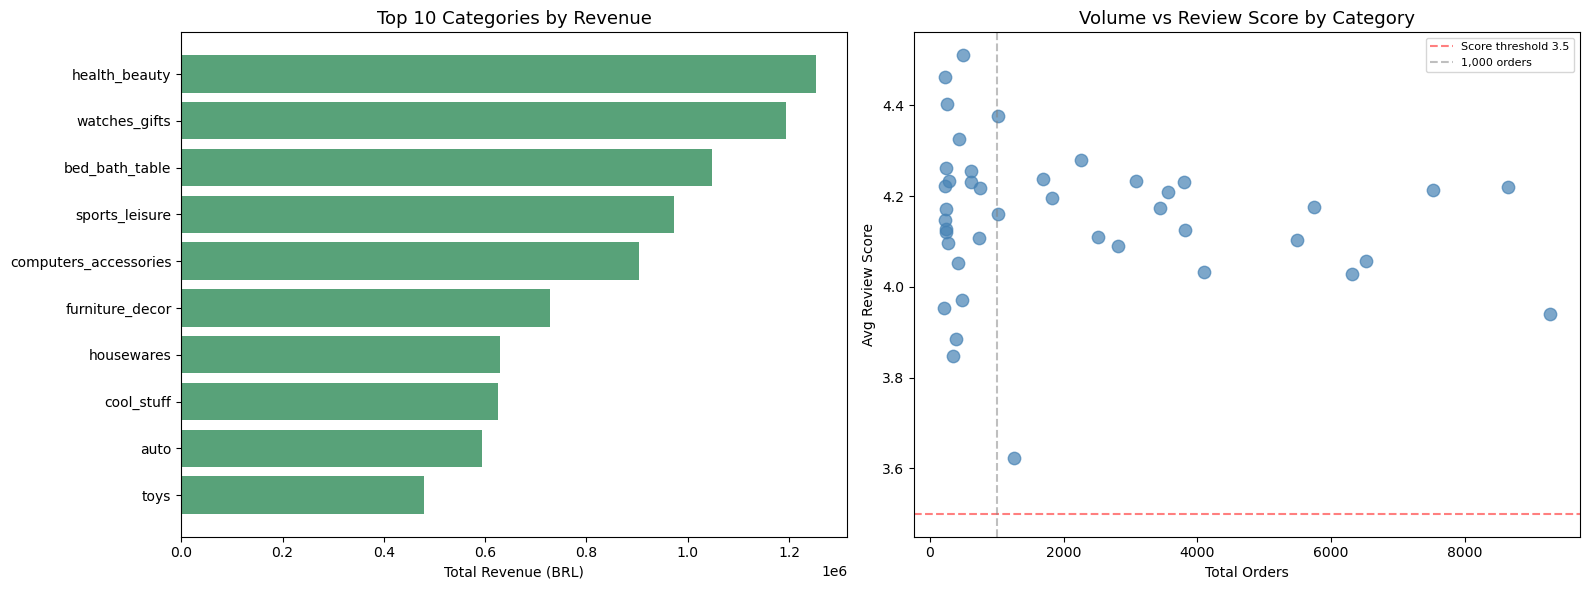

In [180]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── BQ3.1 Top 10 Categories by Revenue ───────────────────
cat_rev = (
    df2.groupby('product_category_name_english')['total_price']
    .sum()
    .nlargest(10)
    .reset_index()
    .sort_values('total_price')
)

axes[0].barh(
    cat_rev['product_category_name_english'],
    cat_rev['total_price'],
    color='seagreen', alpha=0.8
)
axes[0].set_title('Top 10 Categories by Revenue', fontsize=13)
axes[0].set_xlabel('Total Revenue (BRL)')

# ── BQ3.4 Volume vs Review Score (Scatter) ───────────────
cat_score = (
    df2.groupby('product_category_name_english')
    .agg(
        total_orders = ('order_id',      'nunique'),
        avg_score    = ('review_score',  'mean')
    )
    .reset_index()
    .dropna()
)
cat_score = cat_score[cat_score['total_orders'] >= 200]

axes[1].scatter(
    cat_score['total_orders'],
    cat_score['avg_score'],
    alpha=0.7, s=80, color='steelblue'
)

# เส้น threshold
axes[1].axhline(y=3.5,  color='red',  linestyle='--',
                alpha=0.5, label='Score threshold 3.5')
axes[1].axvline(x=1000, color='gray', linestyle='--',
                alpha=0.5, label='1,000 orders')

# Label จุดที่น่าสนใจ
concern = cat_score[
    (cat_score['total_orders'] >= 1000) &
    (cat_score['avg_score']    <= 3.5)
]
for _, row in concern.iterrows():
    axes[1].annotate(
        row['product_category_name_english'],
        (row['total_orders'], row['avg_score']),
        fontsize=7, ha='left',
        xytext=(5, 0), textcoords='offset points'
    )

axes[1].set_title('Volume vs Review Score by Category', fontsize=13)
axes[1].set_xlabel('Total Orders')
axes[1].set_ylabel('Avg Review Score')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(output_pict + "/BQ3_product.png", dpi=150)
plt.show()

<>:66: SyntaxWarning: invalid escape sequence '\B'
<>:66: SyntaxWarning: invalid escape sequence '\B'
C:\Users\Phongsathorn\AppData\Local\Temp\ipykernel_31616\463185737.py:66: SyntaxWarning: invalid escape sequence '\B'
  plt.savefig(output_pict + "\BQ4_delivery.png", dpi=150)


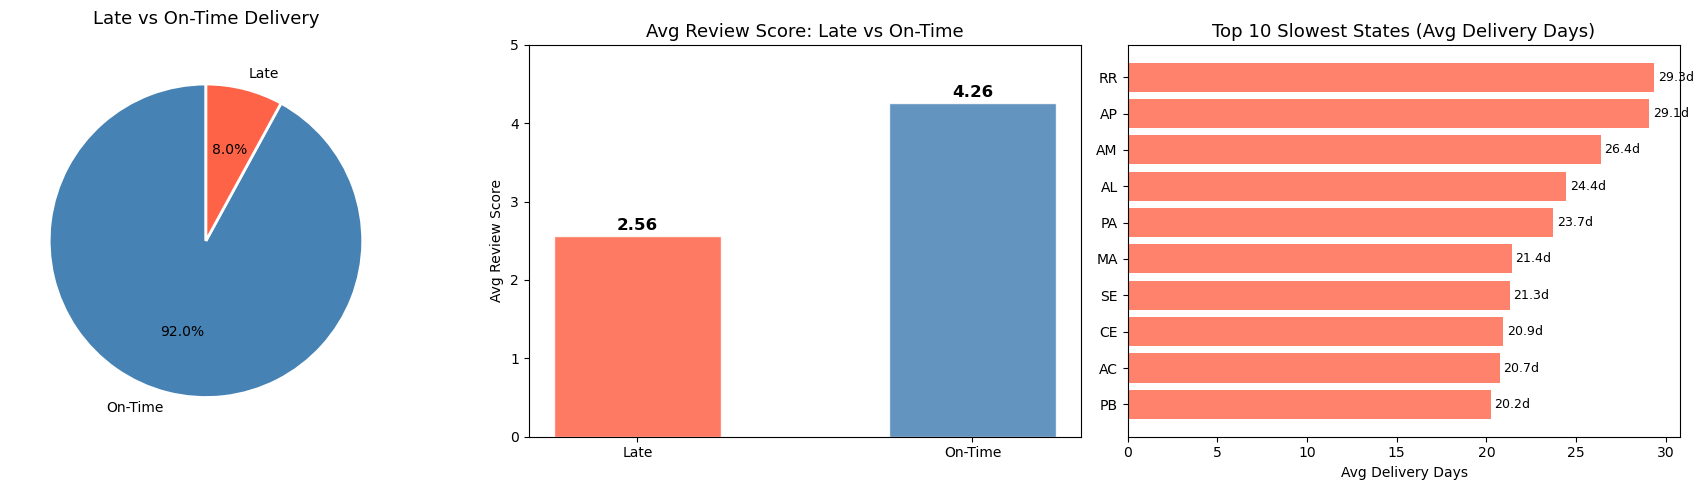

Late delivery rate : 7.96%
On-Time score      : 4.26
Late score         : 2.56
Score drop         : 39.9%


In [181]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── BQ4.1 Late vs On-Time Pie ────────────────────────────
d = df2[df2['actual_delivery_days'].notna()].copy()
late_counts = d['is_late'].value_counts()

axes[0].pie(
    [late_counts.get(0, 0), late_counts.get(1, 0)],
    labels     = ['On-Time', 'Late'],
    autopct    = '%1.1f%%',
    colors     = ['steelblue', 'tomato'],
    startangle = 90,
    wedgeprops = {'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Late vs On-Time Delivery', fontsize=13, pad=15)

# ── BQ4.4 Late → Review Score ────────────────────────────
late_review = (
    d.assign(status=lambda x: x['is_late'].map({1: 'Late', 0: 'On-Time'}))
    .groupby('status')['review_score']
    .mean()
    .reset_index()
)

bars = axes[1].bar(
    late_review['status'],
    late_review['review_score'],
    color=['tomato', 'steelblue'],
    alpha=0.85,
    width=0.5,
    edgecolor='white'
)
axes[1].set_ylim(0, 5)
axes[1].set_title('Avg Review Score: Late vs On-Time', fontsize=13)
axes[1].set_ylabel('Avg Review Score')

for bar in bars:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.08,
        f'{bar.get_height():.2f}',
        ha='center', fontsize=12, fontweight='bold'
    )

# ── BQ4.2 Avg Delivery Days by State (Top 10 ช้าสุด) ─────
state_days = (
    d.groupby('customer_state')['actual_delivery_days']
    .mean()
    .nlargest(10)
    .reset_index()
    .sort_values('actual_delivery_days')
)

axes[2].barh(
    state_days['customer_state'],
    state_days['actual_delivery_days'],
    color='tomato', alpha=0.8
)
axes[2].set_title('Top 10 Slowest States (Avg Delivery Days)', fontsize=13)
axes[2].set_xlabel('Avg Delivery Days')

for i, v in enumerate(state_days['actual_delivery_days']):
    axes[2].text(v + 0.2, i, f'{v:.1f}d', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(output_pict + "\BQ4_delivery.png", dpi=150)
plt.show()

# ── Insight ──────────────────────────────────────────────
late_rate = d['is_late'].mean() * 100
on_time_score = late_review.loc[
    late_review['status'] == 'On-Time', 'review_score'].values[0]
late_score = late_review.loc[
    late_review['status'] == 'Late', 'review_score'].values[0]
drop_pct = (on_time_score - late_score) / on_time_score * 100

print(f"Late delivery rate : {late_rate:.2f}%")
print(f"On-Time score      : {on_time_score:.2f}")
print(f"Late score         : {late_score:.2f}")
print(f"Score drop         : {drop_pct:.1f}%")

<>:71: SyntaxWarning: invalid escape sequence '\B'
<>:71: SyntaxWarning: invalid escape sequence '\B'
C:\Users\Phongsathorn\AppData\Local\Temp\ipykernel_31616\3285287245.py:71: SyntaxWarning: invalid escape sequence '\B'
  plt.savefig(output_pict + "\BQ6_review.png", dpi=150)


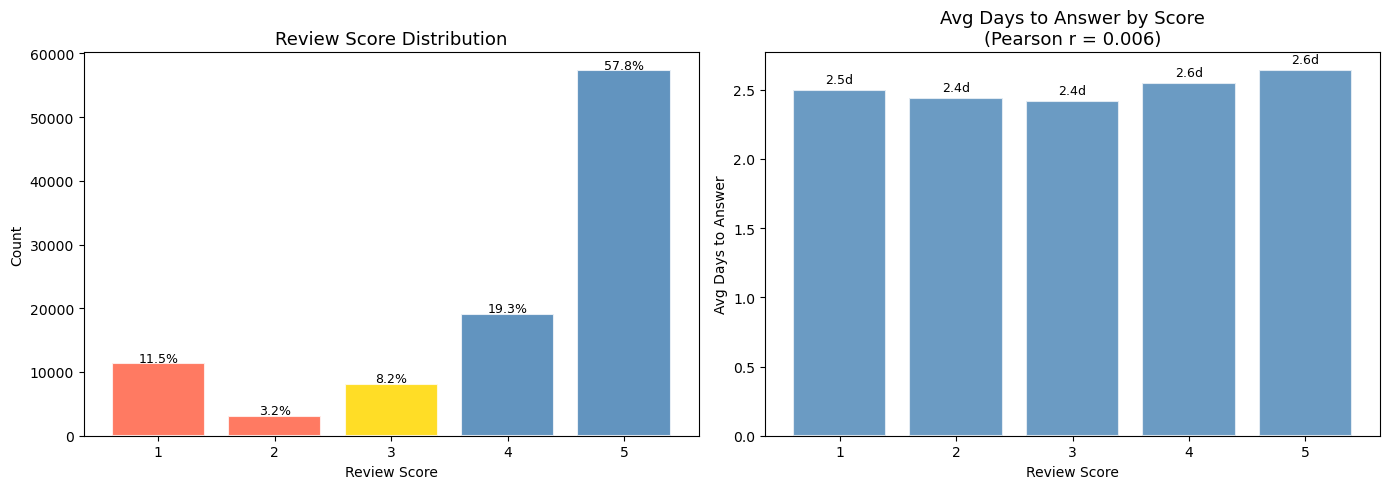

Correlation (score vs days_to_answer) : 0.006
Score 5 — avg days to answer : 2.6
Score 1 — avg days to answer : 2.5


In [182]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── BQ6.1 Review Score Distribution ──────────────────────
score_dist = (
    review['review_score']
    .value_counts()
    .sort_index()
    .reset_index()
)
score_dist.columns = ['score', 'count']
score_dist['pct'] = score_dist['count'] / score_dist['count'].sum() * 100

colors = ['tomato', 'tomato', 'gold', 'steelblue', 'steelblue']
bars = axes[0].bar(
    score_dist['score'],
    score_dist['count'],
    color=colors, alpha=0.85,
    edgecolor='white', linewidth=1.5
)
axes[0].set_title('Review Score Distribution', fontsize=13)
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Count')
axes[0].set_xticks([1, 2, 3, 4, 5])

for bar, pct in zip(bars, score_dist['pct']):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f'{pct:.1f}%',
        ha='center', fontsize=9
    )

# ── BQ6.3 Days to Answer vs Review Score ─────────────────
review['days_to_answer'] = (
    review['review_answer_timestamp'] -
    review['review_creation_date']
).dt.days

score_ans = (
    review.groupby('review_score')['days_to_answer']
    .mean()
    .reset_index()
)

axes[1].bar(
    score_ans['review_score'],
    score_ans['days_to_answer'],
    color='steelblue', alpha=0.8,
    edgecolor='white', linewidth=1.5
)

# Correlation
corr = review[['review_score', 'days_to_answer']].corr().iloc[0, 1]
axes[1].set_title(
    f'Avg Days to Answer by Score\n(Pearson r = {corr:.3f})',
    fontsize=13
)
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Avg Days to Answer')
axes[1].set_xticks([1, 2, 3, 4, 5])

for i, row in score_ans.iterrows():
    axes[1].text(
        row['review_score'],
        row['days_to_answer'] + 0.05,
        f"{row['days_to_answer']:.1f}d",
        ha='center', fontsize=9
    )

plt.tight_layout()
plt.savefig(output_pict + "\BQ6_review.png", dpi=150)
plt.show()

# ── Insight ──────────────────────────────────────────────
print(f"Correlation (score vs days_to_answer) : {corr:.3f}")
print(f"Score 5 — avg days to answer : "
      f"{score_ans[score_ans['review_score']==5]['days_to_answer'].values[0]:.1f}")
print(f"Score 1 — avg days to answer : "
      f"{score_ans[score_ans['review_score']==1]['days_to_answer'].values[0]:.1f}")

In [183]:
df2.to_csv(r"dataset\Olist_Delivered.csv",index=False)